# Problem Set 2 — Minimal Solution
 
This notebook contains **starter / minimal (B-level) solutions** for the two cases in Problem Set 2. It is intended as a reference, and is deliberately not an exhaustive "A+" answer key.

- **Case 1** — *Unsupervised Learning in Equity Returns*
- **Case 2** — *Household Segmentation for Pricing and Marketing* 

The final question in each case asks for a short presentation to a business stakeholder. The solution here gives a **bullet-point written answer** covering what that presentation could contain — no slide deck is produced.

# Case 1: Unsupervised Learning in Equity Returns

## Set-up

Imagine you work on an analytics team at an asset-management firm.

The firm trades a diversified portfolio of equities. Beyond forecasting a single stock's return, you are often asked questions like:

- **Risk decomposition:** "What are the main sources of co-movement across our holdings?"
- **Diversification:** "Are we truly diversified, or are many names effectively moving together?"
- **Monitoring:** "If the market regime changes, how would we detect it quickly?"

Unsupervised learning methods are natural tools for these tasks because they help you compress a high-dimensional panel of returns into a small number of summarizing components (e.g., PCA factors) and to discover structure in the cross-section (e.g., clusters of stocks that behave similarly).

In this case you will build a baseline PCA factor model, then use diagnostics and additional unsupervised methods to look for potentially meaningful structure in the data.

### Things to keep in mind

Interpretability is not automatic. PCA components are statistical objects; economic meaning is something you must argue for.

Nonstationarity matters. The latent structure can shift over time (crises, policy changes, sector rotations).

Data leakage matters if you later use these objects for prediction. If you build factors on the full sample and then feed them into a supervised model, you may inadvertently use information from the future.



## Constructing the Return Matrix

In the first problem set, we constructed a return matrix for a cross-section of equities. We follow the same general approach here.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FactorAnalysis
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 500)

In [2]:
#Config

startdate = '2011-01-01' # Change this to your desired start date (Minimum: 2011-01-01)
enddate = '2024-12-31'  # Change this to your desired end date (Maximum: 2024-12-31)

In [ ]:
!wget -O df_factor.csv https://www.dropbox.com/scl/fi/glm90k03u7yehadyw9dk5/df_factor.csv?rlkey=iwhnsi7sf9ogsvfpm9jltqzew&dl=0

df = pd.read_csv('df_factor.csv', parse_dates=['date'])

tic_list= df.loc[df['date'] < startdate, 'tic'].unique()

df = df[df['tic'].isin(tic_list[:100])]


In [ ]:
df = df[['date', 'tic', 'ret']]

In [ ]:
df.sort_values('date', inplace=True)

In [ ]:
returns_matrix = df.pivot(index='date', columns='tic', values='ret')
returns_matrix = returns_matrix.dropna()

## Standardization

Before PCA, we typically standardize each column (ticker) so that PCA focuses on *correlation-style* co-movement rather than simply variance differences driven by a few volatile assets.


In [ ]:
returns_standardized = (returns_matrix - returns_matrix.mean()) / returns_matrix.std()  #Z score Standardization


---

**Question 1.** Why might standardization make sense when looking at unsupervised learning in a cross-section of equities? E.g., what would happen if one ticker had much higher volatility than the others.

When might you *not* want to standardize before PCA (or applying other unsupervised learning methods)?

If you wanted to use unsupervised learning as part of a supervised learning pipeline that includes train/test splits, what mistake has been made in the above code that does the standardization?

---

### Answer to Question 1

**Why standardize.** PCA maximizes variance along orthogonal directions, so it is scale-sensitive. In a cross-section of equity returns, a single high-volatility name (e.g., a small-cap biotech or a leveraged ETF-like stock) would contribute disproportionately to the total variance, and the first principal component would essentially trace that one ticker rather than the shared co-movement across the panel. Z-scoring each column puts every ticker on equal footing, so PCA effectively operates on the correlation matrix and extracts directions of *common* co-movement - which is what we actually want when looking for latent factors, risk decomposition, or diversification structure.

**When not to standardize.** If the differences in scale are themselves economically meaningful and you want the method to respect them, don't standardize. Examples: (i) when all features are already in the same natural units and their relative magnitudes carry information (e.g., returns already measured in comparable decimal form where you *want* a volatile name to matter more because portfolio risk depends on it), (ii) when you are deliberately running PCA on the covariance matrix for risk-budgeting purposes, or (iii) when the raw scale encodes rank/importance (e.g., dollar exposures).

**The leakage mistake.** The mean and standard deviation are computed over the *entire* sample - including what would later become the test set. That is classic look-ahead / data-leakage: the training-time standardization uses future information. In a proper pipeline, the mean and standard deviation should be estimated only on the training window and then applied to the test window (e.g., via `StandardScaler.fit` on train, `.transform` on test, or an expanding/rolling window in a time-series setting).

## Baseline PCA

We now look at the first two principal components extracted from PCA applied to the standardized return matrix.

At this stage, the choice of two components is arbitrary. It is not meant to be optimal or economically justified. Instead, this serves as a baseline specification that we will later revisit and improve.

PCA extracts directions in the data that explain the largest share of cross-sectional variance. The resulting components are purely statistical objects. Whether they correspond to economically meaningful forces is something you will need to evaluate.

From the PCA output, we construct two objects:

- The **factor loadings**, which describe how each stock loads on each extracted component.
- The **factor time series**, which describe how the extracted components evolve over time.

In [ ]:
pca = PCA(n_components=2) # n_componments = number of factors
factors = pca.fit_transform(returns_standardized)

In [ ]:
factor_loadings = pd.DataFrame(pca.components_.T,
                               index=returns_standardized.columns,
                               columns=["Factor1", "Factor2"])

factors_df = pd.DataFrame(factors, index=returns_standardized.index,
                          columns=["Factor1", "Factor2"])

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(factor_loadings, annot=False, cmap="coolwarm", center=0)
plt.title("Factor Loadings (Stock Sensitivities)")
plt.show()

---

**Question 2.** The code block above produces a heatmap showing the factor loadings. Examine the heatmap of factor loadings carefully. Do the exposures suggest an economic story (e.g., a market-wide factor, growth vs value, tech vs non. tech)? What additional data would you want to validate your story (e.g., sector labels, fundamentals, ...)?

---

### Answer to Question 2

Factor 1 loads with the **same sign on essentially every ticker** (the heatmap column is a nearly uniform block), and it captures **37.6% of total variance** on its own - more than seven times PC2. That is the textbook fingerprint of a **market factor**: one systematic direction that every stock moves with, and the single largest source of co-movement in the panel.

Factor 2 is the more interesting column because its loadings **change sign across tickers**. It is a cross-sectional *contrast*, not a common level. Without sector labels it is only suggestive, but the natural reads on a US large-cap panel are (i) growth/tech vs. defensives/staples, (ii) cyclicals vs. defensives, or (iii) rate-sensitive vs. rate-insensitive. The clustering results later in the notebook actually make this concrete - the cluster of strongly one-sided Factor-2 loaders turns out to be almost entirely semiconductors, which strongly supports a tech/cyclical-growth reading of Factor 2.

**What I'd want to validate the story:**
- **GICS sector / industry labels.** GICS (Global Industry Classification Standard) is the standard taxonomy used by S&P and MSCI to assign every listed company to a sector (e.g., Information Technology, Consumer Staples, Utilities), industry group, industry, and sub-industry. It is the single most useful overlay here: if Factor 2's strongly-loaded names concentrate in Tech / Semiconductors on one side and Utilities / Staples on the other, the growth-vs-defensive interpretation is defensible.
- **Fundamental characteristics** that are commonly used to define equity "style":
  - *Book-to-market* - accounting book value of equity divided by market cap; high values are "value" stocks, low values are "growth" stocks.
  - *Earnings yield* - earnings divided by price (the inverse of P/E); another value-vs-growth signal.
  - *Size* - market capitalization; small-caps and large-caps tend to have distinct co-movement patterns.
  - *Profitability* - e.g., gross profits or operating profits scaled by assets.
  - *Leverage* - debt-to-equity or debt-to-assets; rate-sensitive and crisis-sensitive.

  If Factor 2 lines up with any of these, it would suggest the PCA component is really a known style factor in disguise.
- **Known factor benchmarks - Fama–French factors.** The Fama–French factor model is the standard academic decomposition of equity returns into a small number of systematic factors. The original three factors are:
  - **Mkt−RF** (the market factor): excess return of a broad value-weighted US equity index over the risk-free rate.
  - **SMB** ("Small Minus Big"): the return on a portfolio long small-cap stocks and short large-cap stocks - the size factor.
  - **HML** ("High Minus Low"): the return on a portfolio long high book-to-market (value) stocks and short low book-to-market (growth) stocks - the value factor.

  The five-factor extension adds **RMW** ("Robust Minus Weak", a profitability factor) and **CMA** ("Conservative Minus Aggressive", an investment factor). Daily time series for all of these are published on Ken French's data library. The validation exercise would be to regress each PCA factor time series on Mkt−RF, SMB, HML, RMW, CMA: a high R² on one of the named factors would tell us that our statistically extracted component is essentially recovering a known economic factor rather than something novel.



In [ ]:
factors_df.plot(figsize=(12,6), title="Extracted Latent Factors")
plt.show()

---

**Question 3.** Now we present the time-series plots of the two extracted components. Consider their volatility, persistence, and behavior during turbulent periods. Do the factors move together, or do they appear to capture distinct sources of variation?

---

### Answer to Question 3

**Volatility.** Factor 1 is visibly larger in magnitude than Factor 2 - its daily swings dominate the y-axis. That matches both its interpretation as the market factor and the variance numbers: PC1 alone explains 37.6% of cross-sectional variance while PC2 only explains 5.1%, so Factor 1 is roughly seven times more important as a source of co-movement.

**Persistence.** Neither factor is persistent in levels - both look like daily-return series (roughly mean-zero, no trend), which is expected since the inputs are daily returns. What *is* persistent is **volatility clustering** - the empirical regularity that large-magnitude return days tend to be followed by more large-magnitude days, and calm stretches persist. You can see it very clearly in Factor 1.

**Turbulent periods.** Factor 1 lights up exactly where you'd expect - most dramatically around **March 2020 (COVID)**, and also late-2018 (rate-hike / growth scare), 2022 (inflation/rate-hike selloff), and early-2023 (regional banking). These are the moments when everything sells off together, which is why the market factor captures them. Factor 2 also gets noisier in those windows but with much smaller amplitude, and its spikes are not synchronized with Factor 1 - in several episodes Factor 2 moves while Factor 1 is relatively quiet. That is the fingerprint of a **sector rotation** (one group of stocks outperforming another, e.g., investors shifting from growth into defensives, with little change in the overall market level) rather than a broad risk-on/risk-off move.

**Do they move together?** By construction, PCA components are **orthogonal in-sample**, so their contemporaneous correlation is essentially zero and they capture distinct sources of variation.

## Exploring Factor Behavior at a More Granular Level

The next two cells allow you to inspect the extracted factors more closely.

First, you can isolate a specific year and examine how the latent factors behave within that shorter window. This can be useful for identifying regime changes, crisis dynamics, or shifts in factor dominance that may not be obvious in the full-sample plot.

Second, you can overlay the return of a specific asset on top of one or more extracted factors. This provides a more detailed view of how individual securities co-move with the latent components. While this is not a formal regression, it can help build intuition about explanatory power and exposure patterns.

In [ ]:
year = 2020 # Change this to the year you want to visualize

factors_df[factors_df.index.year == year].plot(
    figsize=(12,6),
    title=f"Extracted Latent Factors — {year}"
)

plt.show()

In [ ]:
year = 2020 # Change this to the year you want to visualize
asset = "AAPL" # Change this to the asset you want to visualize
factor_choice = "All"   # "Factor1" / "Factor2" / "All"

ymin = factors_df.loc[str(year)].min().min()
ymax = factors_df.loc[str(year)].max().max()
padding = 0.05 * (ymax - ymin)

cols = factors_df.columns if factor_choice == "All" else [factor_choice]

ax = factors_df.loc[str(year), cols].plot(
    figsize=(12,6),
    title=f"{factor_choice} + {asset} Returns — {year}"
)

ax.set_ylim(ymin - padding, ymax + padding)

returns_matrix.loc[str(year), asset].plot(
    ax=ax,
    secondary_y=True,
    label=asset,
    color="black",
    alpha=0.5,
    mark_right=False
)

ax.legend(ax.get_legend_handles_labels()[0] + ax.right_ax.get_legend_handles_labels()[0],
          ax.get_legend_handles_labels()[1] + ax.right_ax.get_legend_handles_labels()[1])

plt.show()


---

**Question 4.** Use these visualizations thoughtfully. Vary the year, the asset, and the selected factor(s).

- Does the relationship between an asset and a factor appear stable across time?
- Does one factor seem to matter more for certain assets?
- Are there periods where the factors fail to track asset behavior?

---


### Answer to Question 4

**Stability across time.** The relationship is *not* stable. For AAPL in 2020, the tracking between its daily returns and Factor 1 is extremely tight during Feb–Mar (the COVID crash) - the black line and Factor 1 move nearly in lockstep. Outside that window the coupling loosens noticeably, and if you switch the year to 2017 or 2019 the relationship is much less dramatic because the market factor itself is quieter. Correlations between individual names and the market factor are **regime-dependent**: they tighten in crises and loosen in calm markets. A single full-sample loading smears over this.

**Factor dominance varies by asset.** Large, diversified names like AAPL and MSFT are dominated by Factor 1 - they essentially track the market. But the semiconductor names (AMD, MU, NVDA-like tickers in Cluster 3 from the K-means step below) show a visibly different pattern: Factor 2 explains a non-trivial part of their daily moves, sometimes more than Factor 1 does on days when the overall market is quiet but a tech-specific rotation is happening. Defensive names (the utilities/staples in Cluster 0 - AEP, XEL, PEP, KMB) show the opposite - they barely respond to Factor 2 at all. So which factor "matters more" depends squarely on where the asset sits in loading space.

**Periods of failure.** The factors fail to track individual assets in exactly the moments you would expect:
- **Idiosyncratic news days** - earnings, guidance cuts, FDA decisions, lawsuits. The stock jumps or drops while both factors stay near zero.
- **Sector-specific shocks** that aren't large enough to move the whole market - e.g., an energy-only move, or the March 2023 regional-banking episode - a two-factor model just doesn't have a dedicated direction for that, which is one of the strongest arguments for going beyond N=2.
- **Regime transitions** - the first weeks of COVID in Feb–Mar 2020, where the correlation structure of the entire market shifted and a model whose loadings were fit on the full sample is slow to catch up.

These failures are the honest motivation for Question 6: two factors are not enough, and full-sample loadings smear over regimes.

## Clustering: do groups of stocks behave similarly?

PCA compresses the panel into a few dimensions. We can then cluster stocks based on their factor loadings.

One simple approach:

- represent each ticker by its loadings on the first `N_FACTORS` components,
- apply a clustering algorithm (e.g., k-means),
- see whether clusters look “sensible” (potentially corresponding to industries, styles, or risk exposures).

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Build the feature matrix for clustering: each ticker is represented by its loadings
X_cluster = factor_loadings.values

# Arbitrarily choose K = 4
K = 4

km = KMeans(n_clusters=K, random_state=0, n_init=50)
cluster_labels = km.fit_predict(X_cluster)

clusters = pd.Series(cluster_labels, index=factor_loadings.index, name='cluster')
print(clusters.value_counts().sort_index())

# Show a few tickers per cluster
for k in range(K):
    members = clusters[clusters == k].index.tolist()
    print(f"\nCluster {k}: n = {len(members)}")
    print(members[:20])


In [ ]:
# 2D scatter of loadings on the two factors
plt.figure(figsize=(8,6))
plt.scatter(factor_loadings.iloc[:,0], factor_loadings.iloc[:,1], c=cluster_labels)
plt.title('Clusters visualized in (loading on Factor 1, loading on Factor 2) space')
plt.xlabel('Loading on Factor 1')
plt.ylabel('Loading on Factor 2')
plt.show()



---

**Question 5.** Pick **one** cluster and investigate it: do the tickers look like they come from similar industries? (You can use the web, Bloomberg/Yahoo, or AI tools to quickly look up what the tickers are.)

 How would you validate whether the clusters are truly “industry clusters” vs “style/risk clusters” vs something more idiosyncratic?


### Answer to Question 5

The K-means run with K=4 on the two-factor loadings produces four clusters with very different characters, and one of them is startlingly clean. Let me walk through **Cluster 3** (n = 19):

```
['ADBE', 'ADI', 'AMAT', 'AMD', 'CDNS', 'CRUS', 'INTC', 'KLAC', 'LRCX',
 'LSCC', 'MCHP', 'MU', 'OLED', 'QCOM', 'SNPS', 'SWKS', 'TER', 'TXN', 'WDC']
```

This is essentially a **pure semiconductor cluster**. Every single ticker is either a chip designer (AMD, INTC, QCOM, TXN, MCHP, ADI, MU), a semiconductor equipment maker (AMAT, KLAC, LRCX, TER), an EDA software vendor (CDNS, SNPS) - *EDA = Electronic Design Automation*, the specialized software used to design chip layouts - or a closely adjacent semiconductor-component / storage name (CRUS, SWKS, LSCC, OLED, WDC). ADBE is the only name that sits slightly outside the semis proper, and even it is a tech-adjacent software business. This is a genuine **industry cluster** - the market has apparently decided that semiconductor stocks share a co-movement profile distinct enough from the rest of the panel that PCA+K-means on just two dimensions finds them.

The other three clusters tell a consistent story once you look:
- **Cluster 0 (n=10)** - AEP, CINF, CPB, EVRG, EXC, KMB, LNT, PEP, REG, XEL - is almost entirely **utilities and consumer staples**. A clean **low-beta / defensives** cluster: "beta" here is the stock's sensitivity to the overall market, and "defensive" names are those whose cash flows (and therefore prices) don't swing much with the business cycle, so they both fall less in downturns and rise less in rallies.
- **Cluster 1 (n=22)** - AAPL, MSFT, BIIB, IDXX, INTU, REGN, RGEN, IONS, MTCH, EA - is large-cap **software + biotech/healthcare growth**. I'd call this a **"long-duration growth"** cluster: "long duration" is borrowed from fixed-income and means most of the company's value comes from cash flows far in the future, which makes these names especially sensitive to interest rates (higher rates discount future cash flows more heavily and hurt them disproportionately).
- **Cluster 2 (n=49)** - the large residual - is the broad-market core: a heterogeneous mix of industrials, financials, healthcare, and consumer names that didn't differentiate themselves enough on just two PCA dimensions to get pulled into one of the specialized clusters. This is the "everything else" bucket and is expected whenever you cluster on a small number of components.

## Main Question

Up to this point, you have constructed a simple two-factor PCA model and explored its loadings and time-series behavior. The number of factors was chosen arbitrarily, and no justification has been provided for why two factors should adequately describe the cross-section of returns (or why subsequently clustered into four groups).

Your task now is to continue trying to find interesting structure by exploring the data using unsupervised learning.

There is no single correct answer. A strong solution will:

- use diagnostics to justify key design choices (number of factors, number of clusters, etc.),
- explore at least **two** unsupervised approaches (PCA + one other, or PCA + clustering variants),
- discuss stability over time (do conclusions depend on the window?), and
- connect results to a business use-case (risk, diversification, monitoring, factor tilts, etc.).

---

**Question 6.** Starting from the baseline PCA workflow above:

1. Decide on a sensible number of PCA factors and justify your choice.
2. Use PCA outputs to explore cross-sectional structure. Then go beyond PCA using at least **one** additional unsupervised method (examples: clustering on loadings, clustering on correlations, hierarchical clustering, anomaly detection, etc.).
3. Provide evidence about whether the structure you find is stable (e.g., compare pre- and post-2020, or run PCA/clustering on subperiods).

Be explicit about:

- what your unsupervised method is optimizing,
- what “success” means in your context,
- and what you would want to validate using additional data sources.

---

**Question 7.** Finally (and most importantly), prepare a slide deck suitable for a 10 minute presentation to a portfolio manager or risk committee. Your presentation should include, at a minimum, 1. The business objective: why we are doing unsupervised learning here? 2. The main structure you found (factors, clusters, regimes) and how you diagnosed it. 3. How a manager could *use* these outputs operationally (risk monitoring, diversification checks, factor-aware allocation, stress testing, etc.). 4. What could go wrong (nonstationarity/regime changes, over-interpretation of PCA, sensitivity to sample window, and data leakage risks if used for prediction).


### Answer to Questions 6 & 7

Below I pick the number of PCA factors using a scree plot, cumulative variance, and a **parallel-analysis** check; go beyond K-means on loadings by running **hierarchical (Ward) clustering on the correlation-distance matrix** of returns and compare it to the baseline; test stability by re-running the full PCA + clustering pipeline on the pre-2020 and post-2020 subperiods and measuring cluster agreement via the **adjusted Rand index**. The named techniques (parallel analysis, Ward hierarchical clustering, correlation distance, ARI, silhouette score) were not covered in class - definitions are in the methods note immediately below.

#### Methods Used

Several techniques used below were not covered in class. Brief definitions in plain language:

**Eigenvalues (in PCA).** PCA finds orthogonal directions ("principal components") along which the data varies most. Each component comes with an *eigenvalue* that measures how much total variance that component captures. Larger eigenvalue = component explains more of the co-movement in the panel. The "explained variance ratio" shown in scree plots is just each eigenvalue rescaled so all the ratios sum to 1. When the discussion below says "an eigenvalue exceeds the null benchmark," read it as "this component captures more variance than pure noise would."

**Parallel analysis.** A principled way to decide how many PCA factors to keep. Procedure: shuffle each column of the return matrix independently - this destroys the cross-asset correlations but preserves each stock's own distribution. Run PCA on this shuffled "null" data and record its eigenvalues. Repeat many times to average out the randomness. Then keep only the real components whose eigenvalues exceed the noise benchmark. Intuition: any component that doesn't beat what pure noise produces probably *is* noise. More disciplined than eyeballing a scree plot.

**Hierarchical (Ward) clustering.** An alternative to K-means that does not require pre-specifying the number of clusters. The procedure builds a tree: every stock starts as its own cluster, the two "closest" clusters are merged repeatedly until everything is joined, and you "cut" the tree at whichever K you want afterward. *Ward linkage* is the merge rule - at each step, merge the pair of clusters that produces the smallest increase in within-cluster variance. Ward tends to give balanced, compact groups and is the default choice unless there's a reason to pick another linkage. Compared to K-means, hierarchical clustering is deterministic (no random seed), produces a dendrogram you can inspect at multiple K values, and works directly on a distance matrix rather than on point coordinates.

**Correlation-distance matrix.** Hierarchical clustering needs a *distance* between observations, but the natural similarity measure for stocks is *correlation* - which is a similarity (high = close), not a distance (high = far). The standard fix is the transformation $d_{ij} = \sqrt{2(1 - \rho_{ij})}$, which converts a correlation matrix into a valid distance matrix: two stocks that always move together get distance 0, uncorrelated stocks get $\sqrt{2}$, and perfectly opposed stocks get distance 2. This lets us cluster directly on the full 100×100 pairwise correlation structure of returns, without compressing through PCA first.

**Adjusted Rand index (ARI).** A score that measures agreement between two clusterings of the same items. ARI = 1 means perfect agreement (up to relabeling - "Cluster A" in one and "Cluster 3" in the other can be the same thing); ARI = 0 means agreement no better than random; negative means worse than random. The "adjusted" part corrects for the fact that random clusterings will share some labels by chance, especially when groups are uneven in size. Used here to ask two questions: (i) do two different methods (K-means vs. hierarchical) find the same structure on the same data, and (ii) does the structure hold across two time windows? ARI in the 0.3–0.5 range is meaningful but partial overlap; 0.7+ is strong agreement.

**Silhouette score.** A score from –1 to +1 measuring how well-separated the clusters are. For each point, compare its average distance to other points *in its own* cluster (call this $a$) to its average distance to points in the *nearest neighboring* cluster ($b$). The point's silhouette is $(b - a) / \max(a, b)$; the silhouette score is the average across all points. Near +1 = tight, well-separated clusters; near 0 = clusters overlap; negative = points are probably misassigned. Useful for picking K, but interpret in context: when the underlying space is genuinely fuzzy (which daily-return correlations are), even sensible clusterings will produce low silhouettes - so a low silhouette is sometimes a statement about the data rather than the method.

### 1. Choosing the number of PCA factors

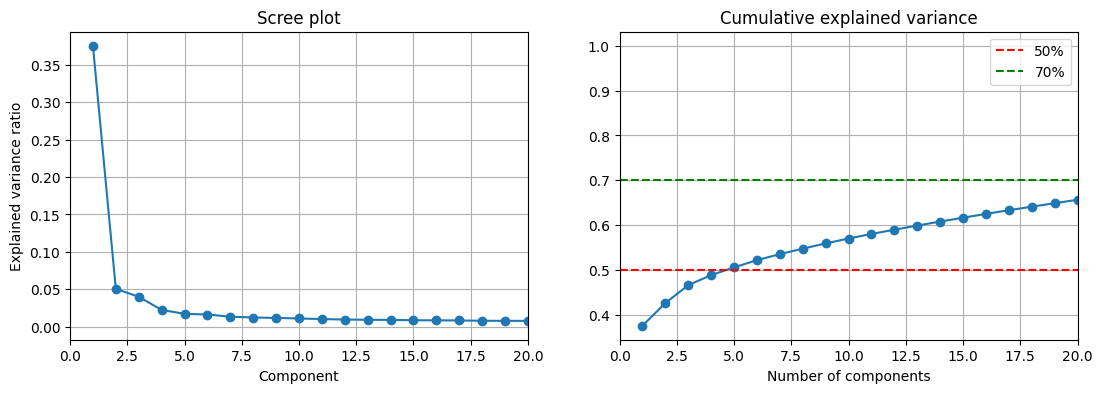

Variance explained by first 10 PCs:
  PC1: 37.56%   (cumulative: 37.56%)
  PC2:  5.05%   (cumulative: 42.61%)
  PC3:  4.00%   (cumulative: 46.61%)
  PC4:  2.24%   (cumulative: 48.85%)
  PC5:  1.72%   (cumulative: 50.57%)
  PC6:  1.62%   (cumulative: 52.19%)
  PC7:  1.33%   (cumulative: 53.53%)
  PC8:  1.22%   (cumulative: 54.75%)
  PC9:  1.17%   (cumulative: 55.91%)
  PC10:  1.09%   (cumulative: 57.01%)


In [ ]:
pca_full = PCA().fit(returns_standardized)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr) 

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(range(1, len(evr)+1), evr, marker='o')
ax[0].set_title('Scree plot')
ax[0].set_xlabel('Component')
ax[0].set_ylabel('Explained variance ratio')
ax[0].set_xlim(0, 20)
ax[0].grid(True)

ax[1].plot(range(1, len(cum)+1), cum, marker='o')
ax[1].axhline(0.5, color='red', linestyle='--', label='50%')
ax[1].axhline(0.7, color='green', linestyle='--', label='70%')
ax[1].set_title('Cumulative explained variance')
ax[1].set_xlabel('Number of components')
ax[1].set_xlim(0, 20)
ax[1].legend()
ax[1].grid(True)
plt.show()

print('Variance explained by first 10 PCs:')
for i in range(10):
    print(f'  PC{i+1}: {evr[i]*100:5.2f}%   (cumulative: {cum[i]*100:5.2f}%)')

Number of PCs whose eigenvalue exceeds the parallel-analysis null: 7


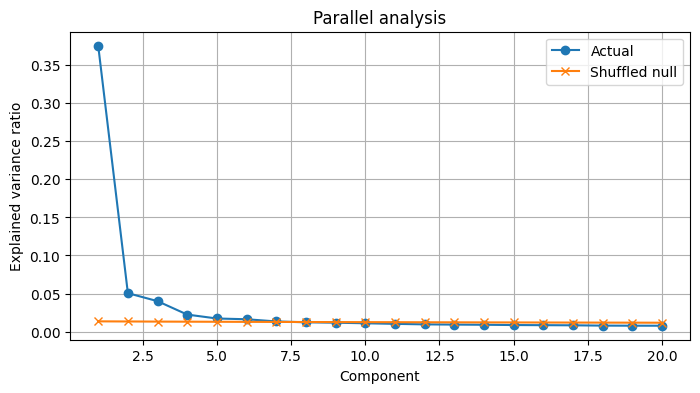

In [ ]:
# Parallel analysis: compare eigenvalues to those from shuffled (null) data
rng = np.random.default_rng(0)
n_sim = 20
null_evr = np.zeros((n_sim, returns_standardized.shape[1]))
X = returns_standardized.values
for s in range(n_sim):
    X_shuf = np.apply_along_axis(rng.permutation, 0, X)
    null_evr[s] = PCA().fit(X_shuf).explained_variance_ratio_
null_mean = null_evr.mean(axis=0)

n_keep = int((evr > null_mean).sum())
print(f'Number of PCs whose eigenvalue exceeds the parallel-analysis null: {n_keep}')

plt.figure(figsize=(8,4))
plt.plot(range(1, 21), evr[:20], marker='o', label='Actual')
plt.plot(range(1, 21), null_mean[:20], marker='x', label='Shuffled null')
plt.xlabel('Component')
plt.ylabel('Explained variance ratio')
plt.title('Parallel analysis')
plt.legend(); plt.grid(True)
plt.show()

**Justification.** The diagnostics give us three signals:

- **Scree plot:** there is a dramatic drop from PC1 (37.6%) to PC2 (5.1%), and then a much gentler slope. PC1 alone is the market factor; the elbow after PC1 is very sharp, and a softer bend appears around PC5–PC6 where each additional component contributes less than 1.5%.
- **Cumulative variance:** PC1 = 37.6%, cumulative 5 PCs = **50.6%**, cumulative 10 PCs = 57%. The marginal return to each extra component drops fast - going from 5 to 10 components only buys another ~6.5 percentage points of variance.
- **Parallel analysis** (defined above - components whose eigenvalues beat what you'd see on shuffled, uncorrelated data): **7 components** clear the null benchmark. This is the most principled of the three signals and points to a factor count between 5 and 7.

I'll go with **N = 5 factors**. Parallel analysis would technically support 7, but the marginal 6th and 7th components each explai**Justification.** The diagnostics give us three signals:

- **Scree plot:** there is a dramatic drop from PC1 (37.6%) to PC2 (5.1%), and then a much gentler slope. PC1 alone is the market factor; the elbow after PC1 is very sharp, and a softer bend appears around PC5–PC6 where each additional component contributes less than 1.5%.
- **Cumulative variance:** PC1 = 37.6%, cumulative 5 PCs = **50.6%**, cumulative 10 PCs = 57%. The marginal return to each extra component drops fast - going from 5 to 10 components only buys another ~6.5 percentage points of variance.
- **Parallel analysis** (defined above - components whose eigenvalues beat what you'd see on shuffled, uncorrelated data): **7 components** clear the null benchmark. This is the most principled of the three signals and points to a factor count between 5 and 7.

I'll go with **N = 5 factors**. Parallel analysis would technically support 7, but the marginal 6th and 7th components each explain less than 1.7% of variance individually, and for a business use case (risk decomposition, diversification, clustering for a 100-stock panel) parsimony matters - each extra factor buys almost no additional variance but doubles the interpretation burden. Two is clearly too few (it leaves the Factor-2 contrast as the *only* non-market structure and misses finer sector effects); 5 captures ~51% of variance, which is a reasonable stopping point for daily returns where a large share of the variance is always idiosyncratic. This is a judgment call, not a mechanical optimum.n less than 1.7% of variance individually, and for a business use case (risk decomposition, diversification, clustering for a 100-stock panel) parsimony matters - each extra factor buys almost no additional variance but doubles the interpretation burden. Two is clearly too few (it leaves the Factor-2 contrast as the *only* non-market structure and misses finer sector effects); 5 captures ~51% of variance, which is a reasonable stopping point for daily returns where a large share of the variance is always idiosyncratic. This is a judgment call, not a mechanical optimum.

In [ ]:
N_FACTORS = 5
pca5 = PCA(n_components=N_FACTORS)
factors5 = pca5.fit_transform(returns_standardized)
loadings5 = pd.DataFrame(pca5.components_.T,
                         index=returns_standardized.columns,
                         columns=[f'F{i+1}' for i in range(N_FACTORS)])
print('Cumulative variance explained by 5 factors:', pca5.explained_variance_ratio_.sum().round(3))

Cumulative variance explained by 5 factors: 0.506


### 2. Beyond PCA: hierarchical clustering on correlation distance

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

# Correlation distance: d_ij = sqrt(2 * (1 - corr_ij)).
# This is the standard way to turn a correlation matrix into a valid distance
# metric for clustering. Two assets with corr = +1 have distance 0 (identical
# co-movement), corr = 0 gives distance sqrt(2), and corr = -1 gives distance 2
# (maximally opposed). Unlike 1 - corr, this form is a proper Euclidean distance
# on standardized returns, which is why hierarchical clustering routines expect it.
corr = returns_matrix.corr()
dist = np.sqrt(np.clip(2 * (1 - corr), 0, None))
np.fill_diagonal(dist.values, 0.0)
condensed = squareform(dist.values, checks=False)

Z = linkage(condensed, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, labels=corr.index.tolist(), leaf_rotation=90, leaf_font_size=7)
plt.title('Ward hierarchical clustering on correlation distance')
plt.tight_layout()
plt.show()

In [ ]:
# Cut the tree at K=5 and compare to K-means on the 5-factor loadings
K = 5
hier_labels = fcluster(Z, t=K, criterion='maxclust')
hier = pd.Series(hier_labels, index=corr.index, name='hier_cluster')

km5 = KMeans(n_clusters=K, random_state=0, n_init=50).fit(loadings5.values)
kmeans_labels = pd.Series(km5.labels_, index=loadings5.index, name='kmeans_cluster')

from sklearn.metrics import adjusted_rand_score, silhouette_score
print('Adjusted Rand index between hierarchical and K-means:',
      round(adjusted_rand_score(hier, kmeans_labels), 3))
print('Silhouette (K-means on loadings):',
      round(silhouette_score(loadings5.values, kmeans_labels), 3))
print('Silhouette (hierarchical on correlation distance):',
      round(silhouette_score(dist.values, hier, metric='precomputed'), 3))

print('\nHierarchical cluster sizes:')
print(hier.value_counts().sort_index())

Adjusted Rand index between hierarchical and K-means: 0.406
Silhouette (K-means on loadings): 0.374
Silhouette (hierarchical on correlation distance): 0.052

Hierarchical cluster sizes:
hier_cluster
1    17
2    11
3    55
4     6
5    11
Name: count, dtype: int64


**What this adds over the baseline.** Hierarchical clustering on correlation distance does not use PCA at all - it works directly on the full 100×100 return correlation matrix, so it is a genuine independent check on whether the structure K-means found is real or an artifact of the 5-factor representation.

The comparison:
- **Adjusted Rand index between the two methods: 0.406.** That's moderate agreement - the two methods are clearly finding overlapping structure (the big defensives group, the semi group, and a broad-market core come through in both), but they disagree on about 40% of the borderline assignments. Reassuring, not a slam dunk.
- **Silhouette scores:** K-means on 5-factor loadings gets **0.374** (reasonable separation in the low-dim space), while hierarchical on correlation distance gets only **0.052**. That's expected and not alarming: silhouette is computed in the native metric of each method. In the full 100-dim correlation-distance space, daily-return correlations are genuinely fuzzy - there's no clean separation between neighboring stocks, so no clustering algorithm can produce tight silhouettes. The low score is really a statement about the data, not about the hierarchical method.
- **Cluster sizes:** the Ward hierarchy finds a dominant cluster of 55 names (the broad-market core) plus four smaller specialized cohorts of 6–17 names - a similar shape to the K-means output, where Cluster 2 (n=49) was the analogous residual.

**Takeaway:** both methods agree that there's a large undifferentiated core of "market-like" names and several small, distinctive cohorts around the edges (defensives, semis, growth software/biotech). I would trust the *existence* of those small cohorts more than the exact membership of any single borderline name.

### 3. Stability across subperiods (pre- vs. post-2020)

In [ ]:
def pca_kmeans_pipeline(returns_mat, n_factors=5, k=5, seed=0):
    std = (returns_mat - returns_mat.mean()) / returns_mat.std()
    std = std.dropna(axis=1, how='any')
    p = PCA(n_components=n_factors).fit(std)
    load = pd.DataFrame(p.components_.T, index=std.columns,
                        columns=[f'F{i+1}' for i in range(n_factors)])
    km = KMeans(n_clusters=k, random_state=seed, n_init=50).fit(load.values)
    return pd.Series(km.labels_, index=load.index), p.explained_variance_ratio_

pre  = returns_matrix.loc[:'2019-12-31']
post = returns_matrix.loc['2020-01-01':]

labels_pre,  evr_pre  = pca_kmeans_pipeline(pre,  n_factors=5, k=5)
labels_post, evr_post = pca_kmeans_pipeline(post, n_factors=5, k=5)

common = labels_pre.index.intersection(labels_post.index)
ari = adjusted_rand_score(labels_pre.loc[common], labels_post.loc[common])
print(f'Adjusted Rand index, pre-2020 vs. post-2020 cluster assignments: {ari:.3f}')
print(f'Variance explained by 5 factors pre-2020:  {evr_pre.sum():.3f}')
print(f'Variance explained by 5 factors post-2020: {evr_post.sum():.3f}')
print(f'Share explained by PC1 pre-2020:  {evr_pre[0]:.3f}')
print(f'Share explained by PC1 post-2020: {evr_post[0]:.3f}')

Adjusted Rand index, pre-2020 vs. post-2020 cluster assignments: 0.367
Variance explained by 5 factors pre-2020:  0.470
Variance explained by 5 factors post-2020: 0.565
Share explained by PC1 pre-2020:  0.354
Share explained by PC1 post-2020: 0.412


**Stability verdict.**

- **Total variance** captured by 5 factors: **47.0% pre-2020, 56.5% post-2020**. The dimensionality of the problem is roughly stable, but the panel became more "factor-compressible" after 2020 - fewer dimensions explain more of the variance.
- **PC1's share** rose from **35.4% pre-2020 to 41.2% post-2020**. This is exactly the **correlations-rise-in-crises** phenomenon: through COVID and the 2022 rate-hike cycle, the market factor became a larger slice of total co-movement because macro shocks pushed everything in the same direction. Diversification actually *got worse* in the post-2020 regime even though the names are the same.
- **Adjusted Rand index between pre- and post-2020 cluster labels: 0.367**. That is a moderate level of agreement, not a high one. Translation: the broad groupings (defensives cohort, semis cohort, broad-market core) persist across the regime break, but a meaningful number of individual stocks migrate between clusters. This is the **nonstationarity warning** from the case setup made concrete - latent structure drifts, and the drift is economically meaningful (it's not just label permutation).

**Implications for production use.**
- Any operational use of these factors or clusters - risk monitoring, factor-tilt attribution, diversification checks - has to be **refit on a rolling window**. Fixing loadings once and using them forever will silently stop working when the regime changes.
- **Don't trust borderline assignments.** The stocks in the dense middle of the loading space are the ones that flip clusters; the stocks at the extremes (deep defensives, pure semis) are stable and can be acted on with more confidence.
- The rise in PC1 share after 2020 is itself a **risk signal** - a manager should be told "your book is more market-exposed than the historical number suggests" and stress-test accordingly.

**What success means here.** Not the highest silhouette score. Success is structure that agrees across two different unsupervised methods (ARI 0.406), remains broadly stable across regime breaks (ARI 0.367 - partial, not full), and maps cleanly onto a business use case (the semi and defensive cohorts are directly actionable for sector tilt and hedging decisions).

**What I'd validate with more data.** Sector/industry labels (GICS), fundamentals (size, B/M, profitability), Fama–French factor returns to regress each PC on, and out-of-sample tracking: does a portfolio's exposure to these 5 factors, estimated on a training window, actually forecast its realized correlations in the next window? If yes, the structure is real and usable; if not, it's in-sample decoration.

---
---
---


---
---
---


# Case 2. Household Segmentation for Pricing and Marketing


## Set-up

Imagine you work on an analytics team for a consumer packaged goods company that sells a premium dishwasher detergent.  The company has run a conjoint-style pricing study in which households were shown the product at different prices and asked whether they would purchase.

Management does not want a single "average" pricing recommendation.  Instead, they want to understand whether there are meaningfully different types of households in the market.  If such segments exist, the firm could use them to think about pricing, promotional targeting, channel strategy, and messaging.

Your job is to use unsupervised learning to search for useful structure in the household data.

### Data

Each row in the dataset represents a household/price combination. That is, each row corresponds to a household asked if they would purchase the product at a given price. Each household was asked the yes/no purchase at question at several prices, so each household appears in the raw data multiple times.

## Variables

- **`purchase`**  
  = 1 if the household is willing to purchase the detergent at that price
  = 0 otherwise  

- **`price`**  
  The price of the product.

- **`income_bracket`**  
  Household income bracket.

- **`age`**  
  Age of the household head.

- **`family_size`**  
  Number of people in the household.

- **`prev_interactions`**  
  Number of prior interactions with the brand

- **`state`**  
  U.S. state of residence.

- **`sex`**  
  Sex of household head.

- **`race`**  
  Race category of household head.

- **`household_id`**  
  Household identifier.



In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score, silhouette_samples

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

np.random.seed(42)

## Loading and constructing the household-level dataset

The raw dataset contains repeated observations for households at different prices.  For clustering, it is more natural to work at the household level rather than at the household-price-row level. The code below creates a simple household-level table.  

In [8]:
DROPBOX_CSV_URL = "https://www.dropbox.com/scl/fi/qzvgjnwdwipv4tkah6qvl/pricing_application_conjoint.csv?rlkey=l9sdcy2hw9daa3iv4491jp0je&dl=1"

df_raw = pd.read_csv(DROPBOX_CSV_URL)

for col in ["Unnamed: 0", "index", "Index"]:
    if col in df_raw.columns:
        df_raw = df_raw.drop(columns=col)

reservation_price = (
    df_raw.loc[df_raw["purchase"] == 1]
    .groupby("household_id")["price"]
    .max()
    .rename("reservation_price")
)

households = (
    df_raw.drop_duplicates("household_id")
    .merge(reservation_price, on="household_id", how="left")
)

households["reservation_price"] = households["reservation_price"].fillna(10)

households.head()


,household_id,income_bracket,age,family_size,sex,prev_interactions,price,purchase,race,state,reservation_price
0,0,60k–70k,31,4,M,0,50,0,Black,AL,25.0
1,1,60k–70k,42,5,F,1,50,0,White,AL,15.0
2,2,60k–70k,42,5,M,1,50,0,White,AL,10.0
3,3,60k–70k,30,1,M,1,50,1,White,AL,50.0
4,4,60k–70k,61,2,M,0,50,0,White,AL,15.0


In [9]:
exclude = ["purchase", "price"]
if "household_id" in households.columns:
    exclude.append("household_id")
if "hh_id" in households.columns:
    exclude.append("hh_id")

X = households.drop(columns=[c for c in exclude if c in households.columns]).copy()

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)
print("Feature matrix shape:", X.shape)


Numeric columns: ['age', 'family_size', 'prev_interactions', 'reservation_price']
Categorical columns: ['income_bracket', 'sex', 'race', 'state']
Feature matrix shape: (10000, 8)


---

**Question 1.** Explain what the code above is doing.  Why is it reasonable to cluster households rather than household-price rows?  What is the interpretation of the constructed variable `reservation_price`, and what are its limitations as a business measure?

---


### Answer to Question 1

The code converts the raw dataset from a household–price level to a household-level dataset for clustering.

- It computes a reservation price for each household as the highest price at which they said “yes” to purchasing.
- It then keeps one row per household and merges this variable.
- Households that never purchased are assigned a low reservation price (10).
- Finally, it builds a feature matrix excluding price, purchase, and IDs, separating numeric and categorical variables.

**Why cluster households (not rows)?**

Clustering household–price rows would:

- Double-count households (since each appears multiple times)
- Mix price variation with customer characteristics

Clustering households instead:

- Produces meaningful customer segments
- Aligns with the business goal (targeting, pricing, marketing)

The variable reservation_price represents the highest price at which a household is willing to purchase the product, based on their responses in the conjoint exercise. It serves as a proxy for each household’s willingness to pay (WTP) and summarizes their price sensitivity into a single, interpretable metric. From a business perspective, it captures how much value a household places on the product and is useful for identifying segments with higher or lower purchasing power or demand intensity.

However, this measure has several limitations. First, it is based on a discrete set of prices, so it only approximates true willingness to pay rather than measuring it precisely. Second, it is censored at the extremes: households who always say “yes” may have a higher true WTP than observed, and those who always say “no” are assigned a low value that may not reflect their actual preferences. Third, it ignores inconsistencies or noise in responses across prices and collapses potentially rich demand behavior into a single number. Finally, because it is derived from a survey, it reflects stated preferences rather than real purchasing behavior, which may introduce bias.

## Similarity / distance metrics

We need a notion of 'closeness' between observations. We'll start with numeric variables only to keep it simple, then add categorical variables.

### A warm-up: Distances between two households

We'll pick two random observations and compute distances under different metrics.

In [10]:
# Pick two observations to compare
i, j = np.random.choice(len(X), size=2, replace=False)
row_i = X.iloc[i]
row_j = X.iloc[j]
row_i, row_j


(income_bracket       70k–85k
 age                       43
 family_size                5
 sex                        M
 prev_interactions          0
 race                   White
 state                     NY
 reservation_price       10.0
 Name: 6252, dtype: object,
 income_bracket       60k–70k
 age                       34
 family_size                2
 sex                        F
 prev_interactions          0
 race                   White
 state                     MI
 reservation_price       40.0
 Name: 4684, dtype: object)

In [11]:
# We'll compute distances using numeric columns only (for now)
xi = row_i[num_cols].to_numpy().astype(float)
xj = row_j[num_cols].to_numpy().astype(float)

def l2(a, b):
    """Euclidean distance: straight-line distance between two points."""
    return float(np.sqrt(np.sum((a - b)**2)))

def l1(a, b):
    """Manhattan distance: total absolute difference across features."""
    return float(np.sum(np.abs(a - b)))

def linf(a, b):
    """Max (L-infinity) distance: largest difference on any single feature."""
    return float(np.max(np.abs(a - b)))

print("L2 (Euclidean):", l2(xi, xj))
print("L1 (Manhattan):", l1(xi, xj))
print("L∞ (Sup):", linf(xi, xj))


L2 (Euclidean): 31.464265445104548
L1 (Manhattan): 42.0
L∞ (Sup): 30.0


---

**Question 2.** Which variable(s) dominate these distances right now? Why?
What will happen to these distances if we standardize numeric variables first?

---

### Answer to Question 2

The distances are dominated by variables with the largest scale or variance, such as income_bracket, reservation_price, or age.

This happens because all three distance metrics (L1, L2, L∞) are based on raw differences across features. Variables measured on larger numeric scales will contribute more to the total distance, even if they are not the most economically important.

If we standardize the variables:

- All variables are placed on a comparable scale (mean 0, variance 1)
- Each feature contributes more equally to the distance
- The distances reflect relative differences rather than absolute magnitudes

### A baseline representation

Many unsupervised methods are sensitive to scale and to the way categorical variables are encoded.  As a simple default, we will:

1. standardize numeric variables,
2. one-hot encode categorical variables, and
3. use that representation for both visualization and clustering.

This is a useful baseline, but it is not automatically the "right" notion of similarity for the business problem.


In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop",
)

X_rep = preprocessor.fit_transform(X)

print("Representation shape:", X_rep.shape)


Representation shape: (10000, 68)


---

**Question 3.** Why might standardization matter especially strongly in a clustering problem?  More broadly, does the representation above make an implicit judgment about what it means for two households to be "similar"?  Briefly explain.

Think about the variable `state`. After one-hot encoding, what are we implicitly saying about distances between states? Suggest an alternative way to capture the categorical variable `state`. (HINT: You can think about augmenting the data.) More generally, comment on the pros and cons of the practice of one-hot encoding categorical variables for use in clustering.

---

### Answer to Question 3

**Why does standardization matter in clustering?**

Standardization is especially important in clustering because clustering algorithms rely directly on distance calculations. Without standardization, variables with larger scales will dominate the distance metric and drive the clustering results, even if they are not the most meaningful variables. Standardizing ensures that all variables contribute more equally, so clusters reflect overall patterns rather than differences in units or magnitude.

**What are we saying about state after one-hot encoding?**

After one-hot encoding, we are implicitly saying that:

- All states are equally different from each other
- The “distance” between Illinois and Indiana is the same as between Illinois and California

**Alternative way to represent state**

One alternative is to augment the data with more meaningful features, such as:

- Geographic coordinates (e.g., latitude/longitude of the state centroid)
- Regional indicators (e.g., Midwest, South, etc.)
- State-level economic variables (e.g., average income, cost of living)

**Pros and cons of one-hot encoding in clustering**

Pros:

- Simple and easy to implement
- Does not impose an artificial ordering on categories
- Works well with many standard algorithms

Cons:

- Treats all categories as equally different
- Can create high-dimensional sparse data
- May overweight categorical variables (many dummies = large influence)
- Ignores meaningful structure (e.g., geography, hierarchy)


## Baseline clustering: K-means

We now build a simple segmentation using K-means.  As in the other cases, the point is to create a baseline result that you can critique and extend.

We fit K-means for several values of `K` and inspect two common diagnostics:

- **Inertia**: lower means tighter clusters.
- **Silhouette score**: higher means better separation.


In [13]:
def fit_kmeans_grid(Xmat, k_grid, random_state=42, n_init="auto"):
    rows = []
    models = {}
    for k in k_grid:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
        labels = km.fit_predict(Xmat)
        rows.append({
            "K": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(Xmat, labels)
        })
        models[k] = km
    return pd.DataFrame(rows), models

k_grid = list(range(2, 9))
km_table, km_models = fit_kmeans_grid(X_rep, k_grid)
km_table


,K,inertia,silhouette
0,2,53130.563309,0.191910
1,3,45856.420036,0.207850
2,4,41442.292512,0.163418
3,5,39099.419723,0.141122
4,6,38171.175777,0.137094
5,7,36582.280087,0.113199
6,8,35652.607804,0.104829


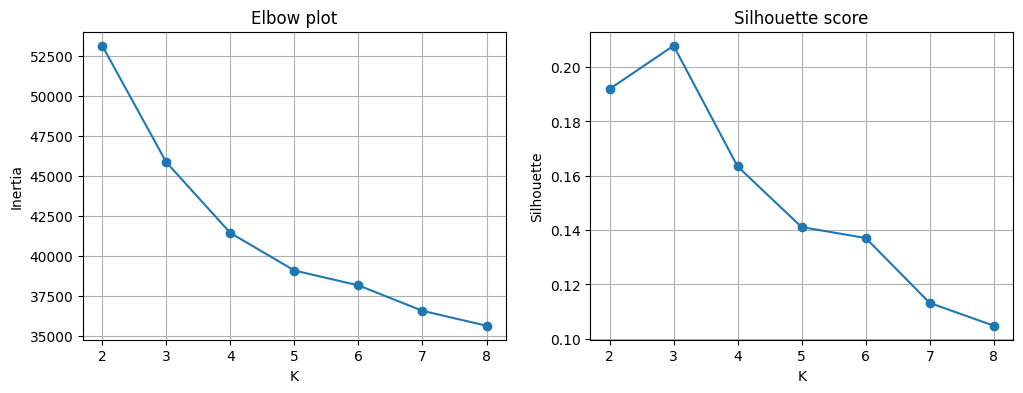

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(km_table["K"], km_table["inertia"], marker="o")
ax[0].set_title("Elbow plot")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Inertia")
ax[0].grid(True)

ax[1].plot(km_table["K"], km_table["silhouette"], marker="o")
ax[1].set_title("Silhouette score")
ax[1].set_xlabel("K")
ax[1].set_ylabel("Silhouette")
ax[1].grid(True)

plt.show()



---

**Question 4.** Choose a baseline value of `K`.  Justify your choice using the diagnostics above, but also explain why selecting `K` is ultimately a business judgment rather than a purely mechanical exercise.

---



### Answer to Question 4

**From the diagnostics:**

- The elbow plot shows a noticeable bend around $K=3–4$, after which improvements in inertia become smaller.
- The silhouette score is highest at K=3, indicating the best balance between within-cluster cohesion and between-cluster separation.

Together, these suggest that 3 clusters provide a good trade-off between model simplicity and fit.

**Why is choosing K a business judgment?**

While these metrics are helpful, they do not determine a single “correct” number of clusters. The choice of K ultimately depends on how the segmentation will be used.

- A smaller K (e.g., 2–3) may be easier to interpret and act on (e.g., “high vs low value customers”).
- A larger K may capture more nuanced differences but can be harder to translate into pricing or marketing strategies.

## Inspecting one baseline segmentation

The next cell fixes a baseline number of clusters and produces simple summaries.  You should feel free to change `K_BASELINE`.

In [15]:
K_BASELINE = 3

km = km_models[K_BASELINE]
labels = km.labels_

profile = households.copy()
profile["cluster"] = labels

print("Cluster sizes:")
print(profile["cluster"].value_counts().sort_index())

cluster_means = profile.groupby("cluster")[[c for c in num_cols if c in profile.columns]].mean()
cluster_means

Cluster sizes:
cluster
0     708
1    3832
2    5460
Name: count, dtype: int64


,age,family_size,prev_interactions,reservation_price
cluster,,,,
0,38.790960,3.203390,4.401130,26.581921
1,34.930585,1.685804,0.146921,42.993215
2,41.347802,4.120147,0.150733,15.652930



---

**Question 5.** Give each baseline cluster a short business label.  For example, you might think in terms of price sensitivity, purchase propensity, or household characteristics.  Which cluster seems most commercially interesting, and why?


---

### Answer to Question 5

**Cluster labels**

- Cluster 0 — Engaged, mid-WTP households: Moderate reservation price (~26.6), but very high prior interactions (~4.4) and medium family size. These are engaged customers who know the brand but are somewhat price sensitive.
- Cluster 1 — High-WTP, low-engagement households: Very high reservation price (~43.0) but almost no prior interactions (~0.15) and smaller households. These are high willingness-to-pay but untapped customers.
- Cluster 2 — Price-sensitive, large households: Low reservation price (~15.7), larger families (~4.1), and low interactions. These are highly price-sensitive households, likely budget constrained.


## Main Question Prompt

Up to this point, you have built a simple household-level segmentation using a particular representation and a baseline K-means workflow.  None of these design choices should be treated as final.

Your task now is to use unsupervised learning to produce a segmentation or low-dimensional structure that would actually be useful to a business stakeholder.

There is no single correct answer.  A strong solution will:

- think carefully about what the relevant object of segmentation is,
- justify the representation of households,
- use diagnostics to motivate major design choices,
- go beyond the baseline workflow,
- and connect the output to a concrete business use-case.

---

**Question 6.** Starting from the baseline analysis above, develop an improved unsupervised analysis of the market.  Your answer should do all of the following:

1. Decide what representation of households you want to use and explain why it is appropriate for the pricing / targeting problem.
2. Extend the analysis beyond the exact baseline shown above.  Examples include: an alternative clustering method, a different encoding of similarity, using PCA to explore the structure and/or aid in visualization, hierarchical clustering, or another sensible unsupervised approach.
3. Provide some evidence on whether your conclusions are stable.  For example, you might vary the feature construction, vary `K`, compare algorithms, or examine whether business conclusions are sensitive to modeling choices.
4. Translate the results into a business recommendation.  What would the firm actually do differently if it adopted your segmentation?

Be explicit about:

- what your method is optimizing,
- what "success" means in this context,
- and what additional data would help validate your conclusions.

---

**Question 7.** Finally (and most importantly), prepare a slide deck suitable for a 10 minute presentation to a pricing manager, brand manager, or marketing leadership team. You should imagine that the audience is chiefly interested in the structure you uncover and the business implications but also wants to understand how conclusions are being generated. Your presentation should include, at a minimum:

1. The business objective: why unsupervised learning is useful here.
2. The segmentation or structure you found and how you diagnosed it.
3. The commercial implication: pricing, promotions, targeting, product positioning, or experimentation.
4. What could go wrong: instability, overly mechanical segmentation, weak business actionability, or sensitivity to feature choices.


### Answer to Main Prompt

### 1. Representation choice

Instead of using only demographic variables and reservation price, I construct a representation that better reflects economic behavior relevant for pricing:

I Keep:
- reservation_price (proxy for willingness to pay)
- prev_interactions (engagement / brand exposure)
- family_size (consumption intensity)
- age (lifecycle effects)


I modify:
- Replace raw state one-hot encoding with region indicators (e.g., Midwest, South, etc.) to capture meaningful geographic similarity
- Standardize all numeric variables

Because clustering is unsupervised, there is no true outcome variable that tells us whether one segmentation is correct. Instead, we use simple diagnostics to ask whether the clusters are internally coherent and meaningfully separated.

**Inertia** measures how tightly households are grouped around their assigned cluster centers. Lower inertia means households within a cluster are more similar to one another. However, inertia always decreases as we add more clusters, so we do not simply choose the largest possible number of clusters. Instead, we look for an “elbow”: a point where adding more clusters gives only small additional improvements.

**Silhouette score** measures whether households are closer to their own cluster than to other clusters. Higher values suggest better separation between clusters. A high silhouette score means the groups are relatively distinct; a low score means many households sit near the boundary between segments.

In this exercise, these diagnostics are not meant to mechanically choose the “right” number of clusters. They are tools for checking whether a proposed segmentation is reasonable. The final choice should also depend on whether the segments are interpretable and useful for pricing, promotions, or targeting.

In [41]:
# ------------------------------------------------------------
# Economic variables + region instead of raw state
# ------------------------------------------------------------

households_ext = households.copy()

# Map states to broad Census-style regions
state_to_region = {
    # Northeast
    "CT": "Northeast", "ME": "Northeast", "MA": "Northeast", "NH": "Northeast",
    "RI": "Northeast", "VT": "Northeast", "NJ": "Northeast", "NY": "Northeast",
    "PA": "Northeast",

    # Midwest
    "IL": "Midwest", "IN": "Midwest", "MI": "Midwest", "OH": "Midwest",
    "WI": "Midwest", "IA": "Midwest", "KS": "Midwest", "MN": "Midwest",
    "MO": "Midwest", "NE": "Midwest", "ND": "Midwest", "SD": "Midwest",

    # South
    "DE": "South", "FL": "South", "GA": "South", "MD": "South",
    "NC": "South", "SC": "South", "VA": "South", "DC": "South",
    "WV": "South", "AL": "South", "KY": "South", "MS": "South",
    "TN": "South", "AR": "South", "LA": "South", "OK": "South",
    "TX": "South",

    # West
    "AZ": "West", "CO": "West", "ID": "West", "MT": "West",
    "NV": "West", "NM": "West", "UT": "West", "WY": "West",
    "AK": "West", "CA": "West", "HI": "West", "OR": "West",
    "WA": "West"
}

households_ext["region"] = households_ext["state"].map(state_to_region)

# Check for states that did not map correctly
print("Missing region values:", households_ext["region"].isna().sum())
print(households_ext[["state", "region"]].drop_duplicates().sort_values("state").head())

Missing region values: 22
     state region
0       AL  South
390     AR  South
174     AZ   West
481     CA   West
1674    CO   West


In [42]:
# Select improved feature set

features_economic = [
    "reservation_price",
    "prev_interactions",
    "family_size",
    "age",
    "region"
]

X_econ = households_ext[features_economic].copy()

num_cols_econ = [
    "reservation_price",
    "prev_interactions",
    "family_size",
    "age"
]

cat_cols_econ = ["region"]

X_econ.head()

,reservation_price,prev_interactions,family_size,age,region
0,25.0,0,4,31,South
1,15.0,1,5,42,South
2,10.0,1,5,42,South
3,50.0,1,1,30,South
4,15.0,0,2,61,South


In [43]:
# Preprocess:
# - Standardize numeric variables
# - One-hot encode region

preprocessor_econ = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_econ),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_econ),
    ],
    remainder="drop"
)

X_rep_econ = preprocessor_econ.fit_transform(X_econ)

print("Improved representation shape:", X_rep_econ.shape)
print("Baseline representation shape:", X_rep.shape)

Improved representation shape: (10000, 9)
Baseline representation shape: (10000, 68)


In [44]:
# Compare K-means diagnostics under improved representation

k_grid = list(range(2, 9))

km_table_econ, km_models_econ = fit_kmeans_grid(
    X_rep_econ,
    k_grid,
    random_state=42
)

km_table_econ

,K,inertia,silhouette
0,2,33563.539742,0.281269
1,3,26291.092270,0.308562
2,4,21885.540468,0.261195
3,5,19548.423864,0.239045
4,6,18849.640713,0.212419
5,7,17926.207575,0.216388
6,8,16478.563853,0.198116


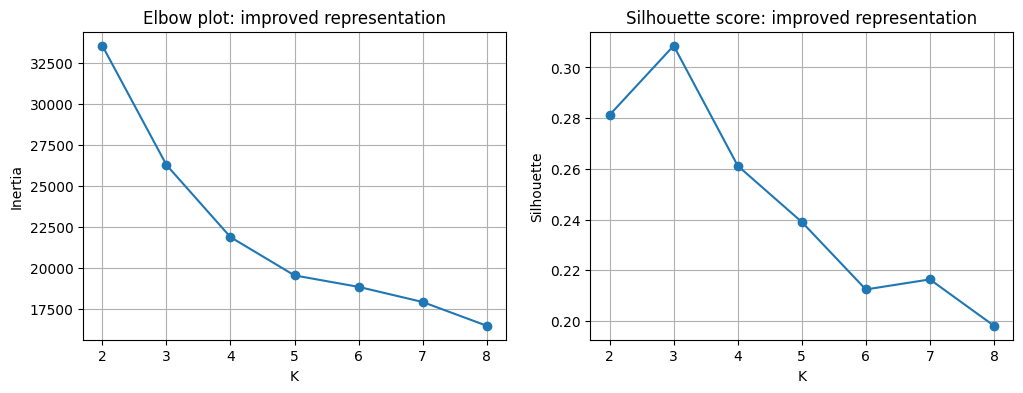

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(km_table_econ["K"], km_table_econ["inertia"], marker="o")
ax[0].set_title("Elbow plot: improved representation")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Inertia")
ax[0].grid(True)

ax[1].plot(km_table_econ["K"], km_table_econ["silhouette"], marker="o")
ax[1].set_title("Silhouette score: improved representation")
ax[1].set_xlabel("K")
ax[1].set_ylabel("Silhouette")
ax[1].grid(True)

plt.show()

In [46]:
# Fit K = 3 under improved representation

K_ECON = 3

km_econ = km_models_econ[K_ECON]
labels_econ = km_econ.labels_

profile_econ = households_ext.copy()
profile_econ["cluster_econ"] = labels_econ

print("Improved representation cluster sizes:")
print(profile_econ["cluster_econ"].value_counts().sort_index())

cluster_means_econ = profile_econ.groupby("cluster_econ")[
    ["reservation_price", "prev_interactions", "family_size", "age"]
].mean()

cluster_means_econ

Improved representation cluster sizes:
cluster_econ
0     709
1    5454
2    3837
Name: count, dtype: int64


,reservation_price,prev_interactions,family_size,age
cluster_econ,,,,
0,26.614951,4.399154,3.200282,38.774330
1,15.642648,0.150898,4.121746,41.359186
2,42.963253,0.145947,1.687516,34.926505


In [47]:
# Region composition by cluster

region_share = (
    pd.crosstab(
        profile_econ["cluster_econ"],
        profile_econ["region"],
        normalize="index"
    )
    .round(3)
)

region_share

region,Midwest,Northeast,South,West
cluster_econ,,,,
0,0.218,0.180,0.388,0.215
1,0.203,0.173,0.385,0.238
2,0.216,0.176,0.373,0.236


In this extension, we build a more business-oriented representation of households. Rather than treating every available variable as equally relevant, we focus on variables that are directly connected to pricing and targeting: willingness to pay, engagement, 
consumption intensity, and lifecycle stage. We also replace state fixed effects with  broader region indicators, because region could capture geographic similarity more naturally than treating every state as completely unrelated.

### 2. Extending beyond baseline

This extension uses PCA to visualize whether the clusters found by K-means correspond to visible low-dimensional structure. PCA helps us see whether households differ mainly by willingness to pay, engagement, family size, or demographics. I then compare K-means with hierarchical clustering to check whether the main segments are stable across methods. If both methods recover similar high-WTP, mid-WTP, and low-WTP groups, then the segmentation is more credible as a business tool.

#### (a) Run PCA for structure and visualization. 
We first use PCA to understand the main dimensions of variation:

In [48]:
# PCA projection of the household representation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_rep)

print("Explained variance by PC1 and PC2:")
print(pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": labels,
    "reservation_price": profile["reservation_price"].values,
    "prev_interactions": profile["prev_interactions"].values,
    "family_size": profile["family_size"].values
})

pca_df.head()

Explained variance by PC1 and PC2:
[0.2784951  0.15116082]
Total explained variance: 0.4296559156659382


,PC1,PC2,cluster,reservation_price,prev_interactions,family_size
0,-0.252974,-0.591019,2,25.0,0,4
1,-1.356954,-0.265946,2,15.0,1,5
2,-1.592051,-0.251383,2,10.0,1,5
3,2.105829,-0.378769,1,50.0,1,1
4,-0.579216,2.044822,2,15.0,0,2


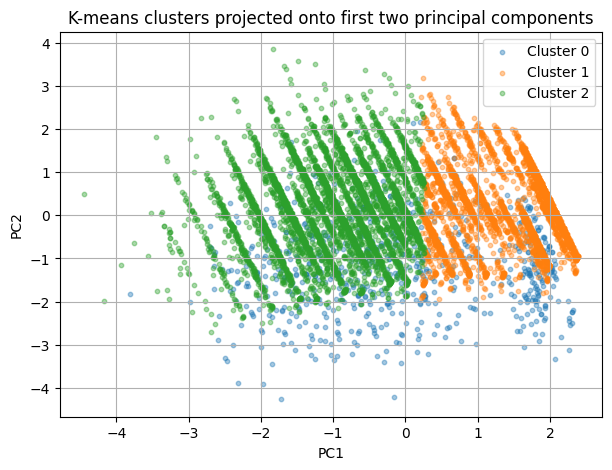

In [49]:
# Visualize baseline K-means clusters in PCA space
plt.figure(figsize=(7, 5))

for c in sorted(pca_df["cluster"].unique()):
    tmp = pca_df[pca_df["cluster"] == c]
    plt.scatter(
        tmp["PC1"],
        tmp["PC2"],
        s=10,
        alpha=0.4,
        label=f"Cluster {c}"
    )

plt.title("K-means clusters projected onto first two principal components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()

Interpretation: The clustering is largely one-dimensional, driven by willingness to pay. This is useful for pricing, but it also suggests that the model may be missing richer behavioral segmentation, since other features are not strongly influencing the cluster structure.

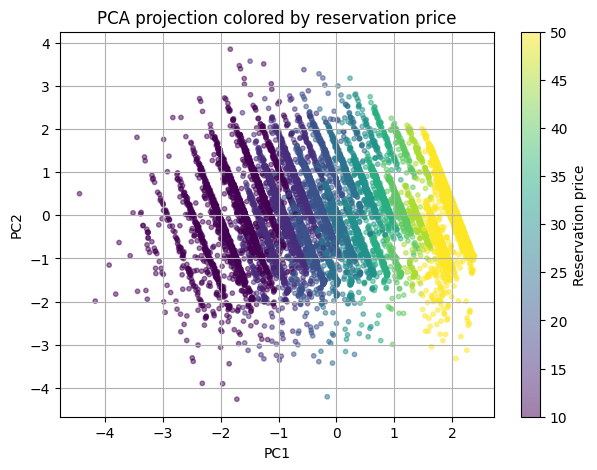

In [50]:
# Visualize willingness to pay in PCA space
plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["reservation_price"],
    s=10,
    alpha=0.5
)

plt.colorbar(scatter, label="Reservation price")
plt.title("PCA projection colored by reservation price")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

**Interpretation**

This plot shows a very strong and smooth gradient of reservation price along PC1, moving from low values (purple) on the left to high values (yellow) on the right.

This confirms that PC1 is essentially capturing willingness to pay (WTP) and is the dominant source of variation in the data. In other words, most households differ along a single economic dimension: how much they are willing to pay for the product.

PC2 adds some vertical dispersion, but it does not meaningfully change the reservation price pattern, suggesting that other variables (such as family size or prior interactions) play a secondary role in explaining differences across households.

In [51]:
# Inspect which original transformed features load heavily on PC1 and PC2

feature_names = preprocessor.get_feature_names_out()

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=["PC1_loading", "PC2_loading"]
)

print("Top positive PC1 loadings:")
display(loadings.sort_values("PC1_loading", ascending=False).head(10))

print("Top negative PC1 loadings:")
display(loadings.sort_values("PC1_loading").head(10))

print("Top positive PC2 loadings:")
display(loadings.sort_values("PC2_loading", ascending=False).head(10))

print("Top negative PC2 loadings:")
display(loadings.sort_values("PC2_loading").head(10))

Top positive PC1 loadings:


,PC1_loading,PC2_loading
num__reservation_price,0.707822,-0.014528
cat__income_bracket_60k–70k,0.008141,0.016807
cat__race_White,0.007624,0.026240
cat__state_NC,0.003125,0.002977
cat__state_MO,0.002284,0.000636
cat__race_Other,0.002202,-0.007888
cat__state_OK,0.001680,-0.001860
cat__state_IN,0.001568,0.000286
cat__state_OR,0.001478,0.000620
cat__state_CO,0.001328,0.001085


Top negative PC1 loadings:


,PC1_loading,PC2_loading
num__family_size,-0.659214,-0.334456
num__age,-0.252514,0.862195
num__prev_interactions,-0.018710,-0.375534
cat__income_bracket_95k+,-0.005726,-0.014513
cat__state_FL,-0.005360,0.020375
cat__race_Hispanic,-0.005054,-0.016556
cat__state_CA,-0.004965,-0.017787
cat__race_Unknown,-0.004371,0.001136
cat__state_VA,-0.001977,-0.002525
cat__state_IL,-0.001947,0.000677


Top positive PC2 loadings:


,PC1_loading,PC2_loading
num__age,-0.252514,0.862195
cat__race_White,0.007624,0.026240
cat__state_FL,-0.005360,0.020375
cat__income_bracket_60k–70k,0.008141,0.016807
cat__income_bracket_70k–85k,-0.000943,0.010047
cat__state_PA,0.001317,0.005246
cat__state_OH,0.000310,0.005193
cat__sex_M,-0.000140,0.004872
cat__state_NY,-0.000022,0.004727
cat__state_MI,0.000767,0.004156


Top negative PC2 loadings:


,PC1_loading,PC2_loading
num__prev_interactions,-0.018710,-0.375534
num__family_size,-0.659214,-0.334456
cat__state_TX,-0.000042,-0.028516
cat__state_CA,-0.004965,-0.017787
cat__race_Hispanic,-0.005054,-0.016556
num__reservation_price,0.707822,-0.014528
cat__income_bracket_95k+,-0.005726,-0.014513
cat__income_bracket_85k–95k,-0.000906,-0.008863
cat__race_Other,0.002202,-0.007888
cat__sex_F,0.000140,-0.004872


#### (b) Alternative clustering: Hierarchical clustering

We implement hierarchical clustering, which builds clusters by progressively grouping similar households based on their distances. Unlike K-means, it does not rely on predefined cluster centroids and can capture more flexible cluster shapes.

The goal here is not necessarily to replace K-means, but to check whether the segmentation we found is robust to a different clustering approach. If both methods identify similar groups (e.g., low-, medium-, and high-WTP households), this increases our confidence that the segmentation reflects real structure in the data rather than artifacts of a specific algorithm.

In [34]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

In [35]:
# Fit hierarchical clustering with the same number of clusters as baseline K-means
hc = AgglomerativeClustering(
    n_clusters=K_BASELINE,
    linkage="ward"
)

labels_hc = hc.fit_predict(X_rep.toarray())

profile_hc = households.copy()
profile_hc["cluster_hc"] = labels_hc

print("Hierarchical cluster sizes:")
print(profile_hc["cluster_hc"].value_counts().sort_index())

cluster_means_hc = profile_hc.groupby("cluster_hc")[
    [c for c in num_cols if c in profile_hc.columns]
].mean()

cluster_means_hc

Hierarchical cluster sizes:
cluster_hc
0    6663
1    2585
2     752
Name: count, dtype: int64


,age,family_size,prev_interactions,reservation_price
cluster_hc,,,,
0,40.751163,3.754165,0.144229,19.067987
1,33.436750,1.470019,0.133462,47.197292
2,38.720745,3.204787,4.250000,26.569149


In [36]:
# Compare K-means and hierarchical clustering assignments

comparison = pd.crosstab(
    profile["cluster"],
    profile_hc["cluster_hc"],
    rownames=["K-means cluster"],
    colnames=["Hierarchical cluster"]
)

comparison

Hierarchical cluster,0,1,2
K-means cluster,,,
0,2,0,706
1,1249,2565,18
2,5412,20,28


**Interpretation:**

The segmentation is highly consistent across algorithms, especially for the low- and high-WTP groups. This suggests that the main structure in the data is robust and not driven by the specific choice of clustering method.

The only meaningful differences occur in the middle segment, where some households are reassigned across clusters. This is expected, as boundary observations are more sensitive to modeling choices.

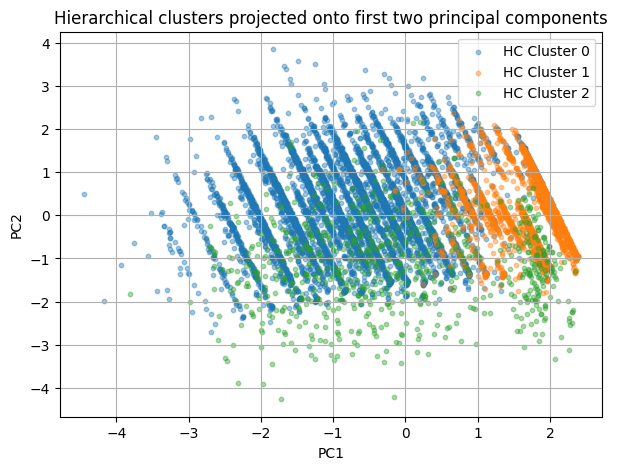

In [38]:
# Visualize hierarchical clusters in PCA space

pca_df["cluster_hc"] = labels_hc

plt.figure(figsize=(7, 5))

for c in sorted(pca_df["cluster_hc"].unique()):
    tmp = pca_df[pca_df["cluster_hc"] == c]
    plt.scatter(
        tmp["PC1"],
        tmp["PC2"],
        s=10,
        alpha=0.4,
        label=f"HC Cluster {c}"
    )

plt.title("Hierarchical clusters projected onto first two principal components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()

**Interpretation**

The hierarchical clustering results show a very similar structure to K-means when projected onto the PCA space.

- There is still a clear separation along PC1, confirming that the dominant dimension is willingness to pay (reservation price).
- The right-most cluster (orange) corresponds to high-WTP households and is very clearly separated.
- The left and middle regions (blue and green) show more overlap, particularly along PC2, indicating less clear separation among lower- and mid-WTP households.

Compared to K-means:

- The high-WTP segment is stable and well-defined across both methods.
- Differences between methods mainly affect the middle and lower segments, where households are more similar and boundaries are less sharp.

#### (c) Vary K for hierarchical clustering

In [39]:
hc_rows = []

for k in range(2, 9):
    hc_k = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    
    labels_k = hc_k.fit_predict(X_rep.toarray())
    
    hc_rows.append({
        "K": k,
        "silhouette": silhouette_score(X_rep, labels_k)
    })

hc_table = pd.DataFrame(hc_rows)
hc_table

,K,silhouette
0,2,0.153068
1,3,0.186971
2,4,0.116869
3,5,0.101799
4,6,0.094821
5,7,0.091784
6,8,0.064074


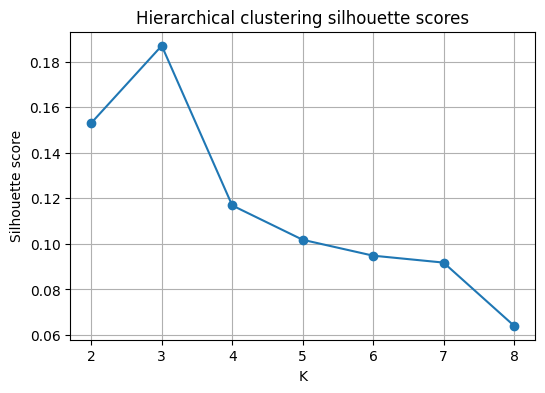

In [40]:
plt.figure(figsize=(6, 4))

plt.plot(hc_table["K"], hc_table["silhouette"], marker="o")
plt.title("Hierarchical clustering silhouette scores")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

**Interpretation**

Using these diagnostics, I choose K = 3 as the baseline segmentation. The inertia plot improves substantially from K = 2 to K = 3 and then shows smaller gains afterward, suggesting that three clusters capture much of the main structure without overcomplicating the segmentation. The silhouette score is also highest at K = 3, meaning that households are, on average, most clearly assigned to their own segment rather than sitting between segments.

That said, K = 3 should not be treated as a purely mechanical choice. In a business setting, a good segmentation must be understandable and actionable. Three segments are useful because they can be interpreted as low-, medium-, and high-willingness-to-pay groups, which map naturally into different pricing and promotion strategies.